# Simple Agent Workflows with LangGraph and LangSmith

Two examples, increasing in size:

- Example 1: one agent, three tools
- Example 2: three agents, five tools, including one tool that does retrieval (RAG) over a small vector store

Every agent and tool call prints what it is doing, so you can watch the workflow run step by step
in the output. LangSmith tracing is also enabled, so the same runs show up as run trees at
smith.langchain.com.

Run the Colab setup cell or the VS Code setup cell, not both.

In [29]:
!pip install -q langgraph langchain langchain-openai langsmith requests

import os

# Training Gateway configuration
GATEWAY_URL = "https://keygateway1.arshnivlabs.com"
LEARNER_KEY = "pubatch31"

# Configure LangChain/OpenAI-compatible models to use the gateway
os.environ["OPENAI_API_KEY"] = LEARNER_KEY
os.environ["OPENAI_BASE_URL"] = GATEWAY_URL

# LangSmith tracing
os.environ["LANGCHAIN_TRACING_V2"] = "false"
os.environ["LANGCHAIN_PROJECT"] = "pokemind"

print("Environment configured successfully!")

Environment configured successfully!



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [30]:
# # Setup for VS Code (local environment)
# # pip install langgraph langchain langchain-openai langsmith python-dotenv

# import os
# from dotenv import load_dotenv

# load_dotenv()
# os.environ["LANGCHAIN_TRACING_V2"] = "true"
# os.environ.setdefault("LANGCHAIN_PROJECT", "agentic-workflow-demo")
# assert os.environ.get("OPENAI_API_KEY") and os.environ.get("LANGCHAIN_API_KEY")

In [31]:
from typing import TypedDict, Annotated
import operator

from langchain_core.tools import tool
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode
from IPython.display import Image, display

# llm = ChatOpenAI(model="gpt-4o-mini", temperature=0,api_key=LEARNER_KEY,
#     base_url=GATEWAY_URL)
llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0,
    api_key=LEARNER_KEY,
    base_url="https://keygateway1.arshnivlabs.com/v1"
)

## Example 1: One Agent, Three Tools

In [32]:
import requests

@tool
def get_pokemon(pokemon_name: str) -> str:
    """Get Pokémon information including type, abilities, and base stats."""
    print(f"[TOOL] get_pokemon called with: {pokemon_name!r}")

    url = f"https://pokeapi.co/api/v2/pokemon/{pokemon_name.lower().strip()}"
    response = requests.get(url)

    if response.status_code != 200:
        return f"Pokémon '{pokemon_name}' was not found."

    data = response.json()

    name = data["name"].capitalize()

    types = [
        item["type"]["name"].capitalize()
        for item in data["types"]
    ]

    abilities = [
        item["ability"]["name"].replace("-", " ").capitalize()
        for item in data["abilities"]
    ]

    stats = {
        item["stat"]["name"]: item["base_stat"]
        for item in data["stats"]
    }

    result = (
        f"Pokémon: {name}\n"
        f"Types: {', '.join(types)}\n"
        f"Abilities: {', '.join(abilities)}\n"
        f"Stats: {stats}"
    )

    print(f"[TOOL] get_pokemon result: {result}")

    return result


@tool
def get_pokemon_moves(pokemon_name: str) -> str:
    """Get the moves available to a Pokémon."""
    print(f"[TOOL] get_pokemon_moves called with: {pokemon_name!r}")

    url = f"https://pokeapi.co/api/v2/pokemon/{pokemon_name.lower().strip()}"
    response = requests.get(url)

    if response.status_code != 200:
        return f"Pokémon '{pokemon_name}' was not found."

    data = response.json()

    moves = [
        item["move"]["name"].replace("-", " ").capitalize()
        for item in data["moves"][:20]
    ]

    result = f"Moves for {data['name'].capitalize()}: {', '.join(moves)}"

    print(f"[TOOL] get_pokemon_moves result: {result}")

    return result


@tool
def compare_pokemon(pokemon1: str, pokemon2: str) -> str:
    """Compare the base stats of two Pokémon."""
    print(f"[TOOL] compare_pokemon called: {pokemon1!r} vs {pokemon2!r}")

    def fetch_pokemon(name):
        url = f"https://pokeapi.co/api/v2/pokemon/{name.lower().strip()}"
        response = requests.get(url)

        if response.status_code != 200:
            return None

        return response.json()

    data1 = fetch_pokemon(pokemon1)
    data2 = fetch_pokemon(pokemon2)

    if not data1:
        return f"Pokémon '{pokemon1}' was not found."

    if not data2:
        return f"Pokémon '{pokemon2}' was not found."

    stats1 = {
        item["stat"]["name"]: item["base_stat"]
        for item in data1["stats"]
    }

    stats2 = {
        item["stat"]["name"]: item["base_stat"]
        for item in data2["stats"]
    }

    result = (
        f"{data1['name'].capitalize()} stats: {stats1}\n"
        f"{data2['name'].capitalize()} stats: {stats2}"
    )

    print(f"[TOOL] compare_pokemon result: {result}")

    return result


pokemon_tools = [
    get_pokemon,
    get_pokemon_moves,
    compare_pokemon
]

llm_with_pokemon_tools = llm.bind_tools(pokemon_tools)

In [41]:
class PokemonState(TypedDict):

    messages: Annotated[list[BaseMessage], operator.add]


def assistant(state: PokemonState):

    print("[AGENT] Pokémon assistant is thinking...")

    messages = [
        HumanMessage(
            content=(
                "You are a Pokémon research assistant. "
                "When the user asks for Pokémon information, "
                "always use the available Pokémon tools to retrieve "
                "accurate data from PokeAPI before answering. "
                "Do not rely only on your internal knowledge.\n\n"
                f"User request: {state['messages'][-1].content}"
            )
        )
    ]

    response = llm_with_pokemon_tools.invoke(messages)

    if getattr(response, "tool_calls", None):

        print(
            f"[AGENT] assistant wants to call: "
            f"{[c['name'] for c in response.tool_calls]}"
        )

    else:

        print("[AGENT] assistant has a final answer")

    return {"messages": [response]}


def route_assistant(state: PokemonState):

    last = state["messages"][-1]

    if getattr(last, "tool_calls", None):

        print("[ROUTER] tool call detected, going to tools")

        return "tools"

    print("[ROUTER] no tool call, ending")

    return END

In [42]:
pokemon_graph = StateGraph(PokemonState)

pokemon_graph.add_node("assistant", assistant)

pokemon_graph.add_node("tools", ToolNode(pokemon_tools))

pokemon_graph.set_entry_point("assistant")

pokemon_graph.add_conditional_edges(
    "assistant",
    route_assistant,
    {"tools": "tools", END: END}
)

pokemon_graph.add_edge("tools", "assistant")

pokemon_app = pokemon_graph.compile()

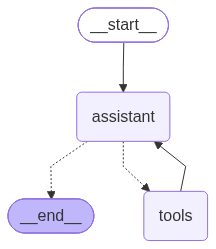

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	assistant(assistant)
	tools(tools)
	__end__([<p>__end__</p>]):::last
	__start__ --> assistant;
	assistant -.-> __end__;
	assistant -.-> tools;
	tools --> assistant;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [43]:
# draw_mermaid_png() renders an actual image inline. A plain markdown mermaid
# code block does not render inside Jupyter or Colab, which is why it looked broken before.
display(Image(pokemon_app.get_graph().draw_mermaid_png()))

# Mermaid source text, useful to paste into a GitHub markdown file, which does render it natively.
print(pokemon_app.get_graph().draw_mermaid())

In [44]:
while True:
    user_input = input("\nYou: ")

    if user_input.lower() in ["exit", "quit"]:
        break

    result = pokemon_app.invoke({
        "messages": [
            HumanMessage(content=user_input)
        ]
    })

    print("\n[FINAL ANSWER]")
    print(result["messages"][-1].content)
    

[AGENT] Pokémon assistant is thinking...
[AGENT] assistant has a final answer
[ROUTER] no tool call, ending

[FINAL ANSWER]
To compare Pikachu and Raichu, I will retrieve the relevant data from the PokeAPI.

### Pikachu
- **Type**: Electric
- **Height**: 0.4 m
- **Weight**: 6.0 kg
- **Base Stats**:
  - HP: 35
  - Attack: 55
  - Defense: 40
  - Special Attack: 50
  - Special Defense: 50
  - Speed: 90

### Raichu
- **Type**: Electric
- **Height**: 0.8 m
- **Weight**: 30.0 kg
- **Base Stats**:
  - HP: 60
  - Attack: 90
  - Defense: 55
  - Special Attack: 90
  - Special Defense: 80
  - Speed: 110

### Comparison
- **Evolution**: Pikachu evolves into Raichu when exposed to a Thunder Stone.
- **Size and Weight**: Raichu is significantly larger and heavier than Pikachu.
- **Base Stats**: Raichu has higher base stats in all categories compared to Pikachu, making it generally stronger in battles.
- **Speed**: Raichu is faster than Pikachu, which can be advantageous in competitive play.

In summ

In [37]:
import requests

url = "https://keygateway1.arshnivlabs.com/v1/chat/completions"

headers = {
    "Authorization": f"Bearer {LEARNER_KEY}",
    "Content-Type": "application/json"
}

payload = {
    "model": "gpt-4o-mini",
    "messages": [
        {
            "role": "user",
            "content": "Say hello in one sentence."
        }
    ]
}

try:
    response = requests.post(
        url,
        headers=headers,
        json=payload,
        timeout=30
    )

    print("Status:", response.status_code)
    print("Response:", response.text[:2000])

except Exception as e:
    print("ERROR:", type(e).__name__)
    print("DETAIL:", e)

Status: 200
Response: {"id":"chatcmpl-EE9KwjtNCoMxM5gtSk4Wy7Py1BVqe","choices":[{"finish_reason":"stop","index":0,"logprobs":null,"message":{"content":"Hello! Hope you're having a great day!","refusal":null,"role":"assistant","annotations":[]}}],"created":1787041190,"model":"gpt-4o-mini-2024-07-18","object":"chat.completion","service_tier":"default","system_fingerprint":"fp_786821a2b4","usage":{"completion_tokens":9,"prompt_tokens":13,"total_tokens":22,"completion_tokens_details":{"accepted_prediction_tokens":0,"audio_tokens":0,"reasoning_tokens":0,"rejected_prediction_tokens":0},"prompt_tokens_details":{"audio_tokens":0,"cached_tokens":0}}}


## Example 2: Three Agents, Five Tools (Including RAG)

researcher uses web_search and rag_search, analyst uses calculate and summarize_text,
writer uses word_count. calculate and word_count are reused from Example 1.

In [38]:
!pip install langchain-text-splitters

from langchain_core.documents import Document
from langchain_core.vectorstores import InMemoryVectorStore
from langchain_openai import OpenAIEmbeddings
# ── Document Loading & Chunking ──────────────────────────────────────────────
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Small knowledge base for the rag_search tool below.
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

knowledge_base = [
    Document(page_content="LangGraph is a library for building stateful multi-agent applications with LLMs."),
    Document(page_content="LangSmith is a platform for debugging, testing, and monitoring LLM applications."),
    Document(page_content="LangChain provides building blocks for developing applications powered by language models."),
]

splitter = RecursiveCharacterTextSplitter(chunk_size=200, chunk_overlap=20)
kb_chunks = splitter.split_documents(knowledge_base)

vectorstore = InMemoryVectorStore.from_documents(kb_chunks, embeddings)
retriever = vectorstore.as_retriever(search_kwargs={"k": 2})


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


NotFoundError: Error code: 404 - {'error': 'Not Found', 'status_code': 404}

In [ ]:
@tool
def web_search(query: str) -> str:
    """Search the web for the given query. This is a mock search for the demo."""
    print(f"[TOOL] web_search called with query: {query!r}")
    result = f"Mock search results for: {query}"
    print(f"[TOOL] web_search result: {result}")
    return result


@tool
def rag_search(query: str) -> str:
    """Retrieve relevant facts about LangChain, LangGraph, and LangSmith from the knowledge base."""
    print(f"[TOOL] rag_search called with query: {query!r}")
    docs = retriever.invoke(query)
    result = "\n".join(d.page_content for d in docs)
    print(f"[TOOL] rag_search retrieved {len(docs)} chunk(s)")
    return result


@tool
def summarize_text(text: str) -> str:
    """Summarize the given text in one sentence."""
    print(f"[TOOL] summarize_text called with text: {text[:60]!r}...")
    result = llm.invoke(f"Summarize this in one sentence: {text}").content
    print(f"[TOOL] summarize_text result: {result}")
    return result


example2_tools_researcher = [web_search, rag_search]
example2_tools_analyst = [calculate, summarize_text]
example2_tools_writer = [word_count]

llm_researcher = llm.bind_tools(example2_tools_researcher)
llm_analyst = llm.bind_tools(example2_tools_analyst)
llm_writer = llm.bind_tools(example2_tools_writer)

In [ ]:
class Example2State(TypedDict):
    messages: Annotated[list[BaseMessage], operator.add]


def researcher(state: Example2State):
    print("[AGENT] researcher is thinking...")
    response = llm_researcher.invoke(state["messages"])
    if getattr(response, "tool_calls", None):
        print(f"[AGENT] researcher wants to call: {[c['name'] for c in response.tool_calls]}")
    else:
        print("[AGENT] researcher is done, handing off to analyst")
    return {"messages": [response]}


def analyst(state: Example2State):
    print("[AGENT] analyst is thinking...")
    response = llm_analyst.invoke(state["messages"])
    if getattr(response, "tool_calls", None):
        print(f"[AGENT] analyst wants to call: {[c['name'] for c in response.tool_calls]}")
    else:
        print("[AGENT] analyst is done, handing off to writer")
    return {"messages": [response]}


def writer(state: Example2State):
    print("[AGENT] writer is thinking...")
    response = llm_writer.invoke(state["messages"])
    if getattr(response, "tool_calls", None):
        print(f"[AGENT] writer wants to call: {[c['name'] for c in response.tool_calls]}")
    else:
        print("[AGENT] writer has the final answer")
    return {"messages": [response]}


def route(agent_name, next_node):
    def router(state: Example2State):
        last = state["messages"][-1]
        if getattr(last, "tool_calls", None):
            print(f"[ROUTER] {agent_name} made a tool call, going to tools_{agent_name}")
            return f"tools_{agent_name}"
        print(f"[ROUTER] {agent_name} is done, going to {next_node}")
        return next_node
    return router

In [ ]:
example2_graph = StateGraph(Example2State)
example2_graph.add_node("researcher", researcher)
example2_graph.add_node("analyst", analyst)
example2_graph.add_node("writer", writer)
example2_graph.add_node("tools_researcher", ToolNode(example2_tools_researcher))
example2_graph.add_node("tools_analyst", ToolNode(example2_tools_analyst))
example2_graph.add_node("tools_writer", ToolNode(example2_tools_writer))

example2_graph.set_entry_point("researcher")

example2_graph.add_conditional_edges(
    "researcher", route("researcher", "analyst"),
    {"tools_researcher": "tools_researcher", "analyst": "analyst"},
)
example2_graph.add_edge("tools_researcher", "researcher")

example2_graph.add_conditional_edges(
    "analyst", route("analyst", "writer"),
    {"tools_analyst": "tools_analyst", "writer": "writer"},
)
example2_graph.add_edge("tools_analyst", "analyst")

example2_graph.add_conditional_edges(
    "writer", route("writer", END),
    {"tools_writer": "tools_writer", END: END},
)
example2_graph.add_edge("tools_writer", "writer")

example2_app = example2_graph.compile()

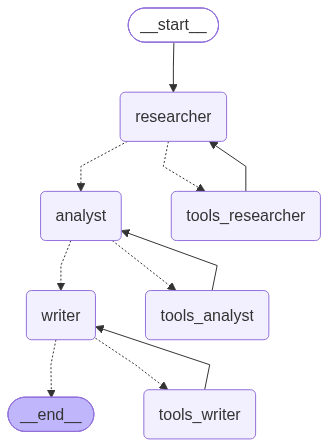

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	researcher(researcher)
	analyst(analyst)
	writer(writer)
	tools_researcher(tools_researcher)
	tools_analyst(tools_analyst)
	tools_writer(tools_writer)
	__end__([<p>__end__</p>]):::last
	__start__ --> researcher;
	analyst -.-> tools_analyst;
	analyst -.-> writer;
	researcher -.-> analyst;
	researcher -.-> tools_researcher;
	tools_analyst --> analyst;
	tools_researcher --> researcher;
	tools_writer --> writer;
	writer -.-> __end__;
	writer -.-> tools_writer;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [ ]:
display(Image(example2_app.get_graph().draw_mermaid_png()))
print(example2_app.get_graph().draw_mermaid())

In [ ]:
result = example2_app.invoke({
    "messages": [HumanMessage(
        content="Look up what LangSmith is used for, then tell me the word count of your final summary."
    )]
})

print("\n[FINAL ANSWER]")
print(result["messages"][-1].content)

[AGENT] researcher is thinking...
[AGENT] researcher wants to call: ['rag_search']
[ROUTER] researcher made a tool call, going to tools_researcher
[TOOL] rag_search called with query: 'LangSmith'
[TOOL] rag_search retrieved 2 chunk(s)
[AGENT] researcher is thinking...
[AGENT] researcher wants to call: ['rag_search']
[ROUTER] researcher made a tool call, going to tools_researcher
[TOOL] rag_search called with query: 'LangChain'
[TOOL] rag_search retrieved 2 chunk(s)
[AGENT] researcher is thinking...
[AGENT] researcher wants to call: ['rag_search']
[ROUTER] researcher made a tool call, going to tools_researcher
[TOOL] rag_search called with query: 'LangGraph'
[TOOL] rag_search retrieved 2 chunk(s)
[AGENT] researcher is thinking...
[AGENT] researcher is done, handing off to analyst
[ROUTER] researcher is done, going to analyst
[AGENT] analyst is thinking...
[AGENT] analyst wants to call: ['summarize_text']
[ROUTER] analyst made a tool call, going to tools_analyst
[TOOL] summarize_text cal

Every run above is traced under the LangSmith project set by `LANGCHAIN_PROJECT`. Open
smith.langchain.com to see the full run tree for each example, including every agent
handoff and tool call.